In [27]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from skimage.measure import shannon_entropy


In [ ]:
# !pip install kaggle
# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# Download entire dataset folder and extract
#!kaggle datasets download -d USERNAME/DATASET-NAME --unzip -p ./data/

# Check what was downloaded
import os
os.listdir("data/")

In [ ]:
dataset_path = "."

data = []

for label in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, label)
    
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            
            path = os.path.join(folder, file)
            
            try:
                img = Image.open(path)
                img = np.array(img)
                
                height, width = img.shape[:2]
                
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                
                brightness = np.mean(gray)
                contrast = np.std(gray)
                
                edges = cv2.Canny(gray,100,200)
                edge_density = np.sum(edges>0) / edges.size
                
                blur = cv2.Laplacian(gray, cv2.CV_64F).var()
                
                file_size = os.path.getsize(path)/1024
                
                entropy_val = shannon_entropy(gray)
                
                data.append({
                    "label":label,
                    "width":width,
                    "height":height,
                    "brightness":brightness,
                    "contrast":contrast,
                    "edge_density":edge_density,
                    "blur":blur,
                    "file_size":file_size,
                    "entropy":entropy_val 
                })
                
            except:
                pass

df = pd.DataFrame(data)

df.head()

,label,width,height,brightness,contrast,edge_density,blur,file_size,entropy
0,cardboard,512,384,150.737030,30.852467,0.012095,79.246007,16.926758,6.703354
1,cardboard,512,384,180.469772,46.405263,0.017034,226.163487,14.535156,6.950417
2,cardboard,512,384,122.484614,71.069240,0.006068,21.678874,13.954102,6.987616
3,cardboard,512,384,159.400055,36.718427,0.009700,89.061845,20.609375,7.086287
4,cardboard,512,384,137.842636,31.513168,0.017741,121.142654,16.821289,6.712060


In [3]:
df = df.dropna()

df = df[df.width>0]
df = df[df.height>0]

df["aspect_ratio"] = df.width/df.height

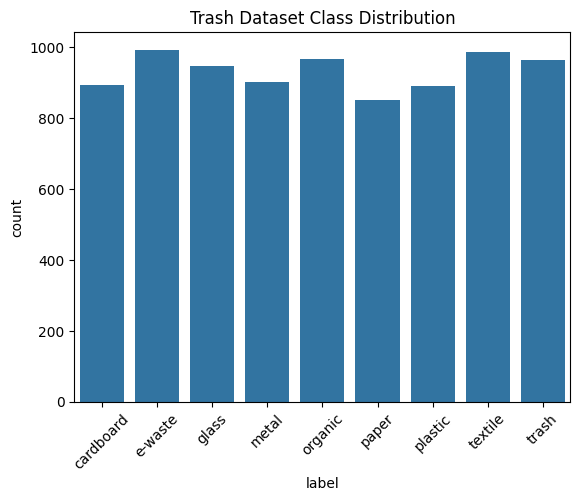

In [ ]:
#bar plot for class imbalance
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df,x="label")
plt.xticks(rotation=45)
plt.title("Trash Dataset Class Distribution")
plt.show()

<Axes: ylabel='count'>

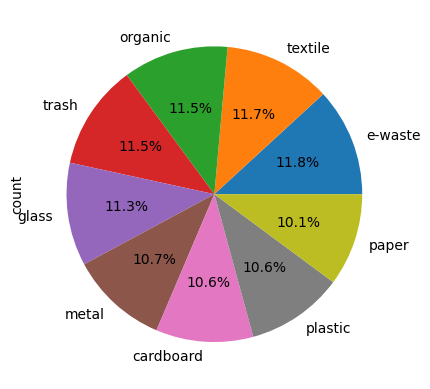

In [ ]:
#dataset composition
df.label.value_counts().plot.pie(autopct="%1.1f%%")

<Axes: xlabel='label'>

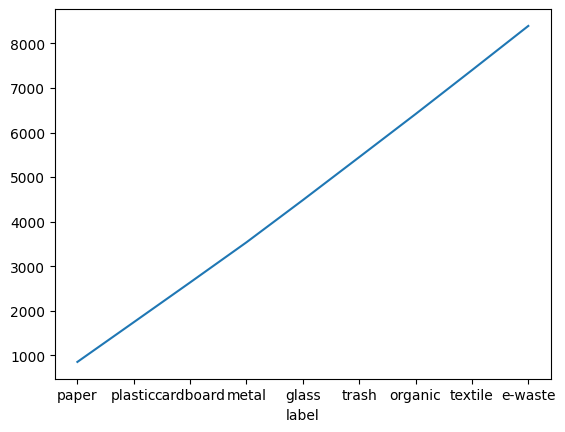

In [ ]:
#images per class - dataset distribution curve
df.label.value_counts().sort_values().cumsum().plot()

<Axes: xlabel='width', ylabel='height'>

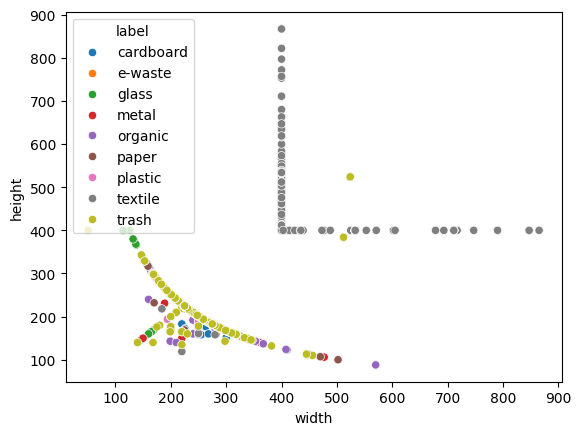

In [ ]:
#image resolution scatter - resolution diversity
sns.scatterplot(x=df.width,y=df.height,hue=df.label)

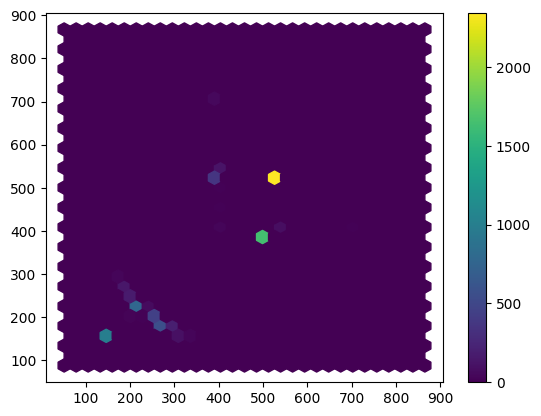

In [13]:
#resolution distribution heatmap
plt.hexbin(df.width,df.height,gridsize=30)
plt.colorbar()

<Axes: xlabel='aspect_ratio', ylabel='Count'>

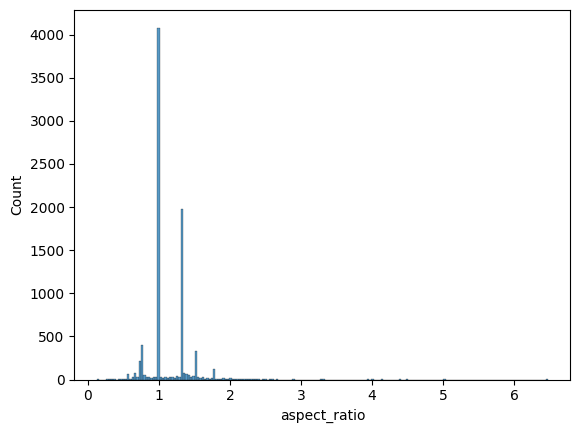

In [ ]:
#Aspect ratio histogram for camera framing patterns
sns.histplot(df.aspect_ratio)

<Axes: xlabel='label', ylabel='aspect_ratio'>

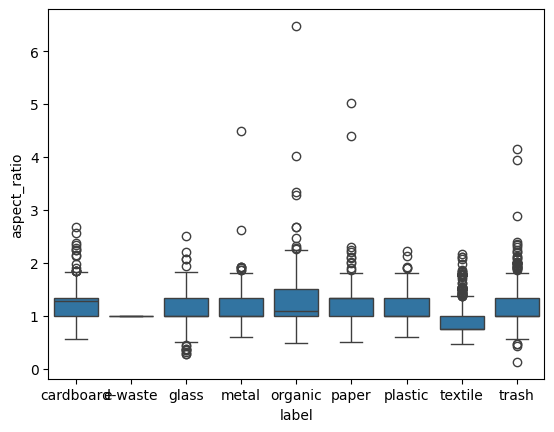

In [15]:

#aspect ratio by class to learn if certain objects ppear in certain shapes
sns.boxplot(x="label",y="aspect_ratio",data=df)

<Axes: xlabel='brightness', ylabel='Count'>

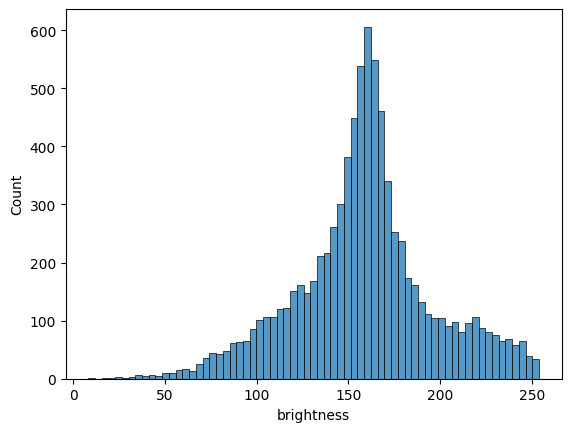

In [16]:
#brightness distribution
sns.histplot(df.brightness)

<Axes: xlabel='label', ylabel='brightness'>

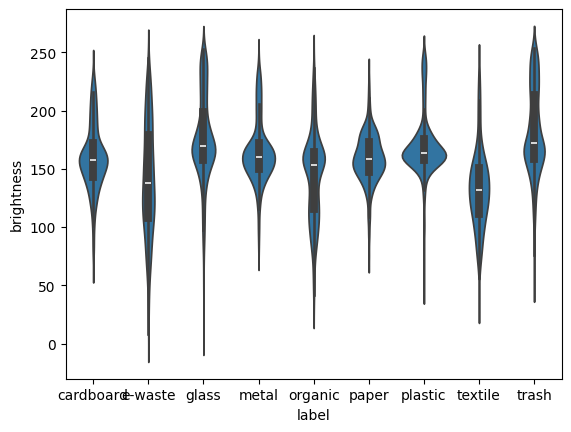

In [ ]:
#Brightness by class to see if some images appear brighter
sns.violinplot(x="label",y="brightness",data=df)

<Axes: xlabel='contrast', ylabel='Count'>

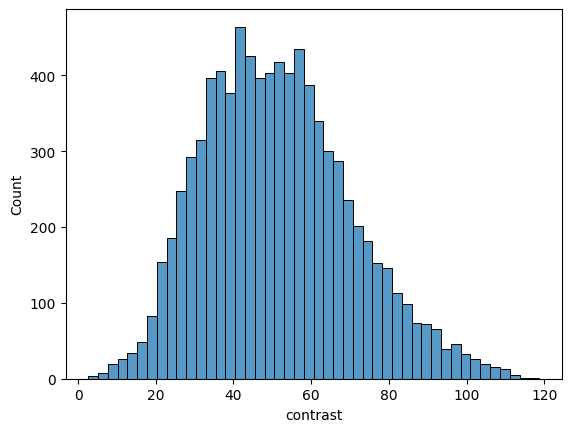

In [18]:
#contrast distribution for texture strength
sns.histplot(df.contrast)

<Axes: xlabel='label', ylabel='contrast'>

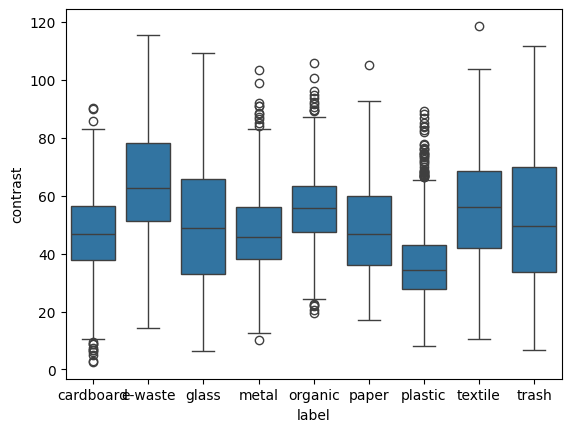

In [19]:
# Contrast by class to determine which materials have stronger texture
sns.boxplot(x="label",y="contrast",data=df)

<Axes: xlabel='edge_density', ylabel='Count'>

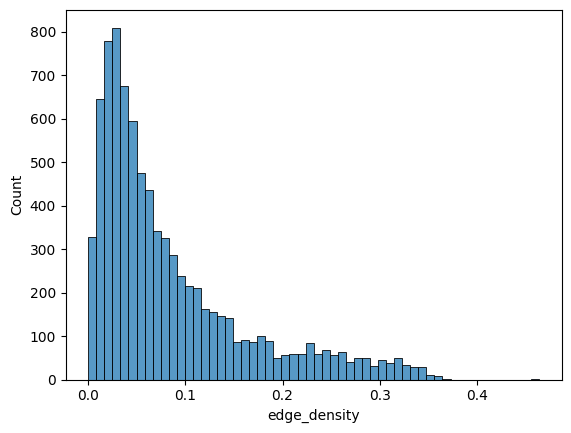

In [20]:
# Edge density distribution for structural complexity
sns.histplot(df.edge_density)

<Axes: xlabel='label', ylabel='edge_density'>

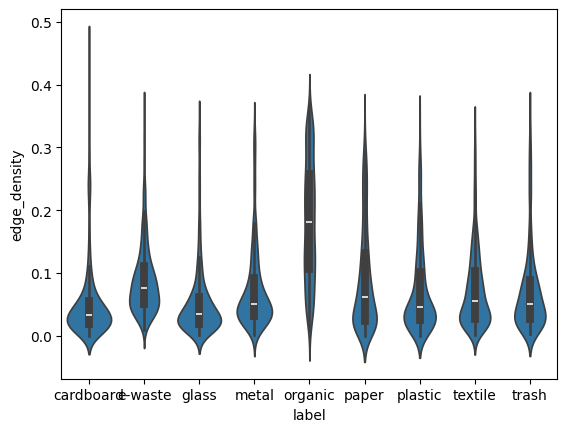

In [21]:
#edge density by class to determine which materials have more structure
sns.violinplot(x="label",y="edge_density",data=df)

<Axes: xlabel='blur', ylabel='Count'>

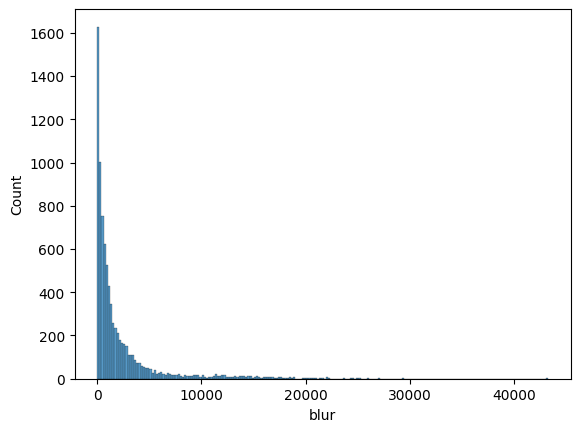

In [22]:
#blur detection - dataset quality
sns.histplot(df.blur)

<Axes: xlabel='label', ylabel='blur'>

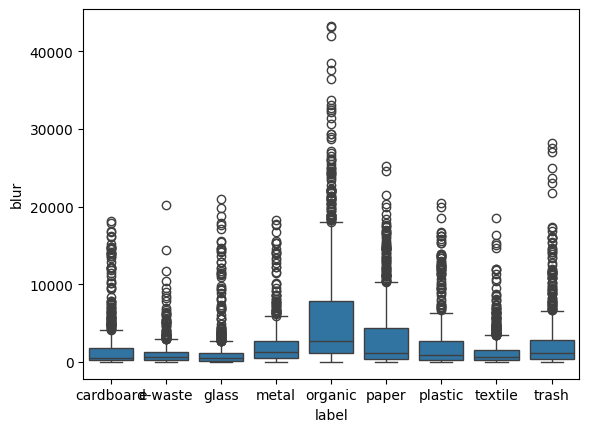

In [23]:
#blur by class to see if some objects were captured poorly
sns.boxplot(x="label",y="blur",data=df)

<Axes: xlabel='entropy', ylabel='Count'>

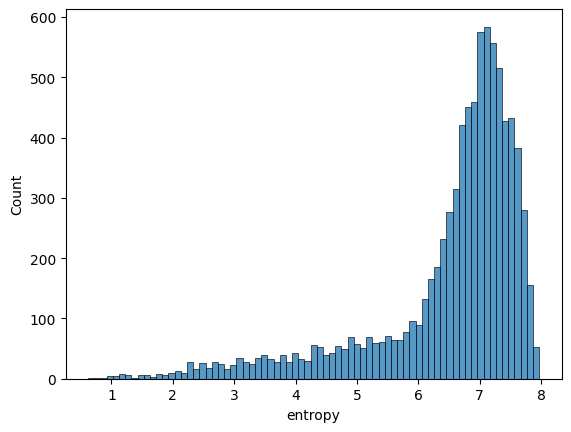

In [36]:
#image entropy for image complexity
sns.histplot(df.entropy)

<Axes: xlabel='label', ylabel='entropy'>

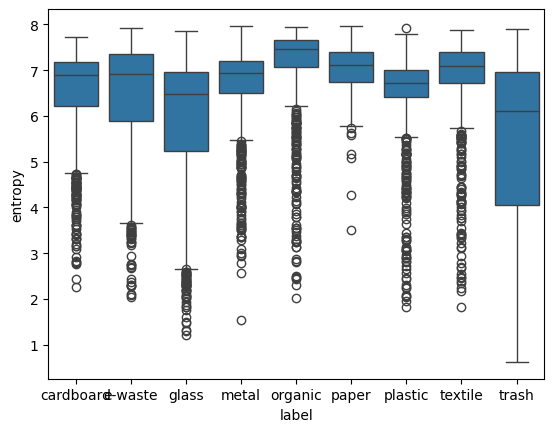

In [31]:
#Entropy by class - which waste types have richer patterns
sns.boxplot(x="label",y="entropy",data=df)

<Axes: xlabel='brightness', ylabel='contrast'>

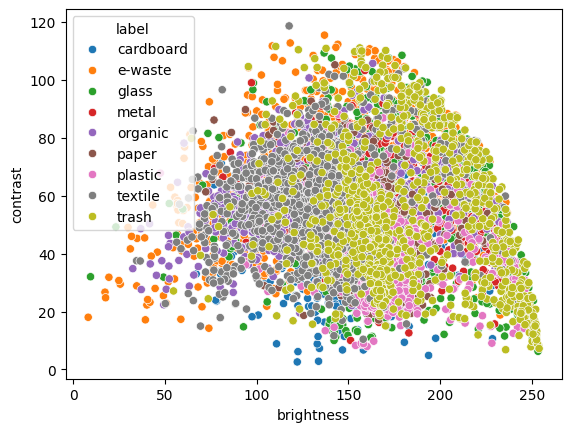

In [32]:
#Brightness vs contrast - lighting vs texture relationship
sns.scatterplot(x="brightness",y="contrast",hue="label",data=df)

<Axes: xlabel='edge_density', ylabel='entropy'>

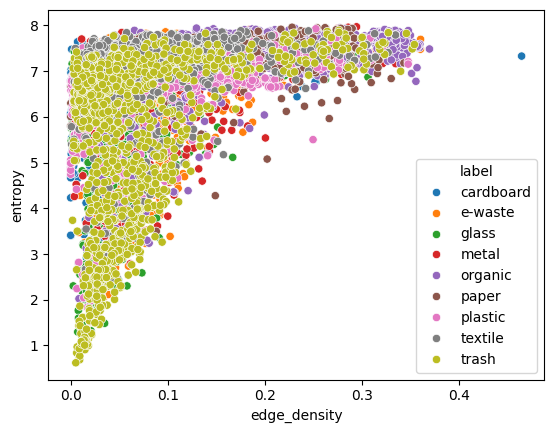

In [33]:
# Edge density vs entropy - structure vs complexity
sns.scatterplot(x="edge_density",y="entropy",hue="label",data=df)

<Axes: xlabel='blur', ylabel='contrast'>

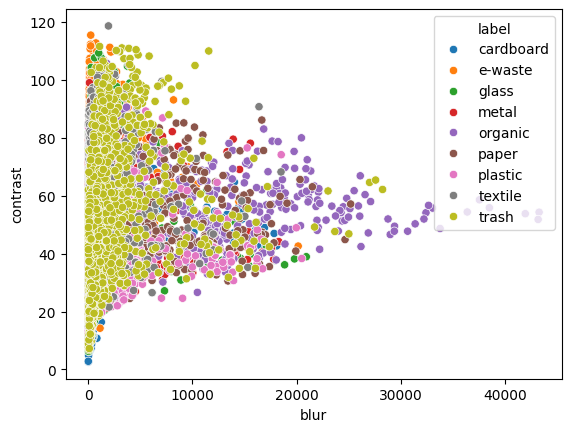

In [34]:
#Blur vs contrast - whether blur reduces texture features
sns.scatterplot(x="blur",y="contrast",hue="label",data=df)

<Axes: >

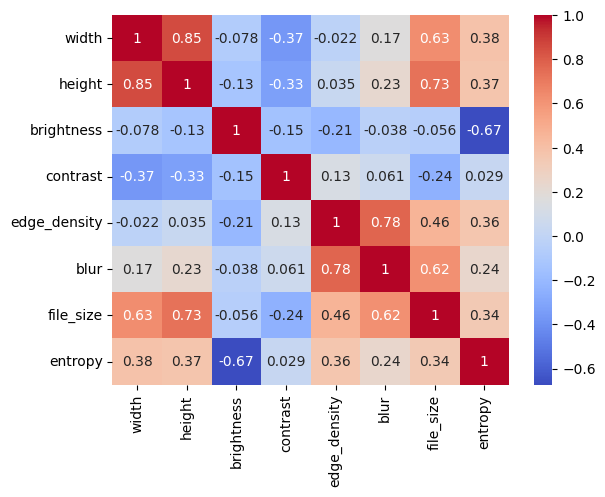

In [37]:
#Feature correlation heatmap - relationships between image properties

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

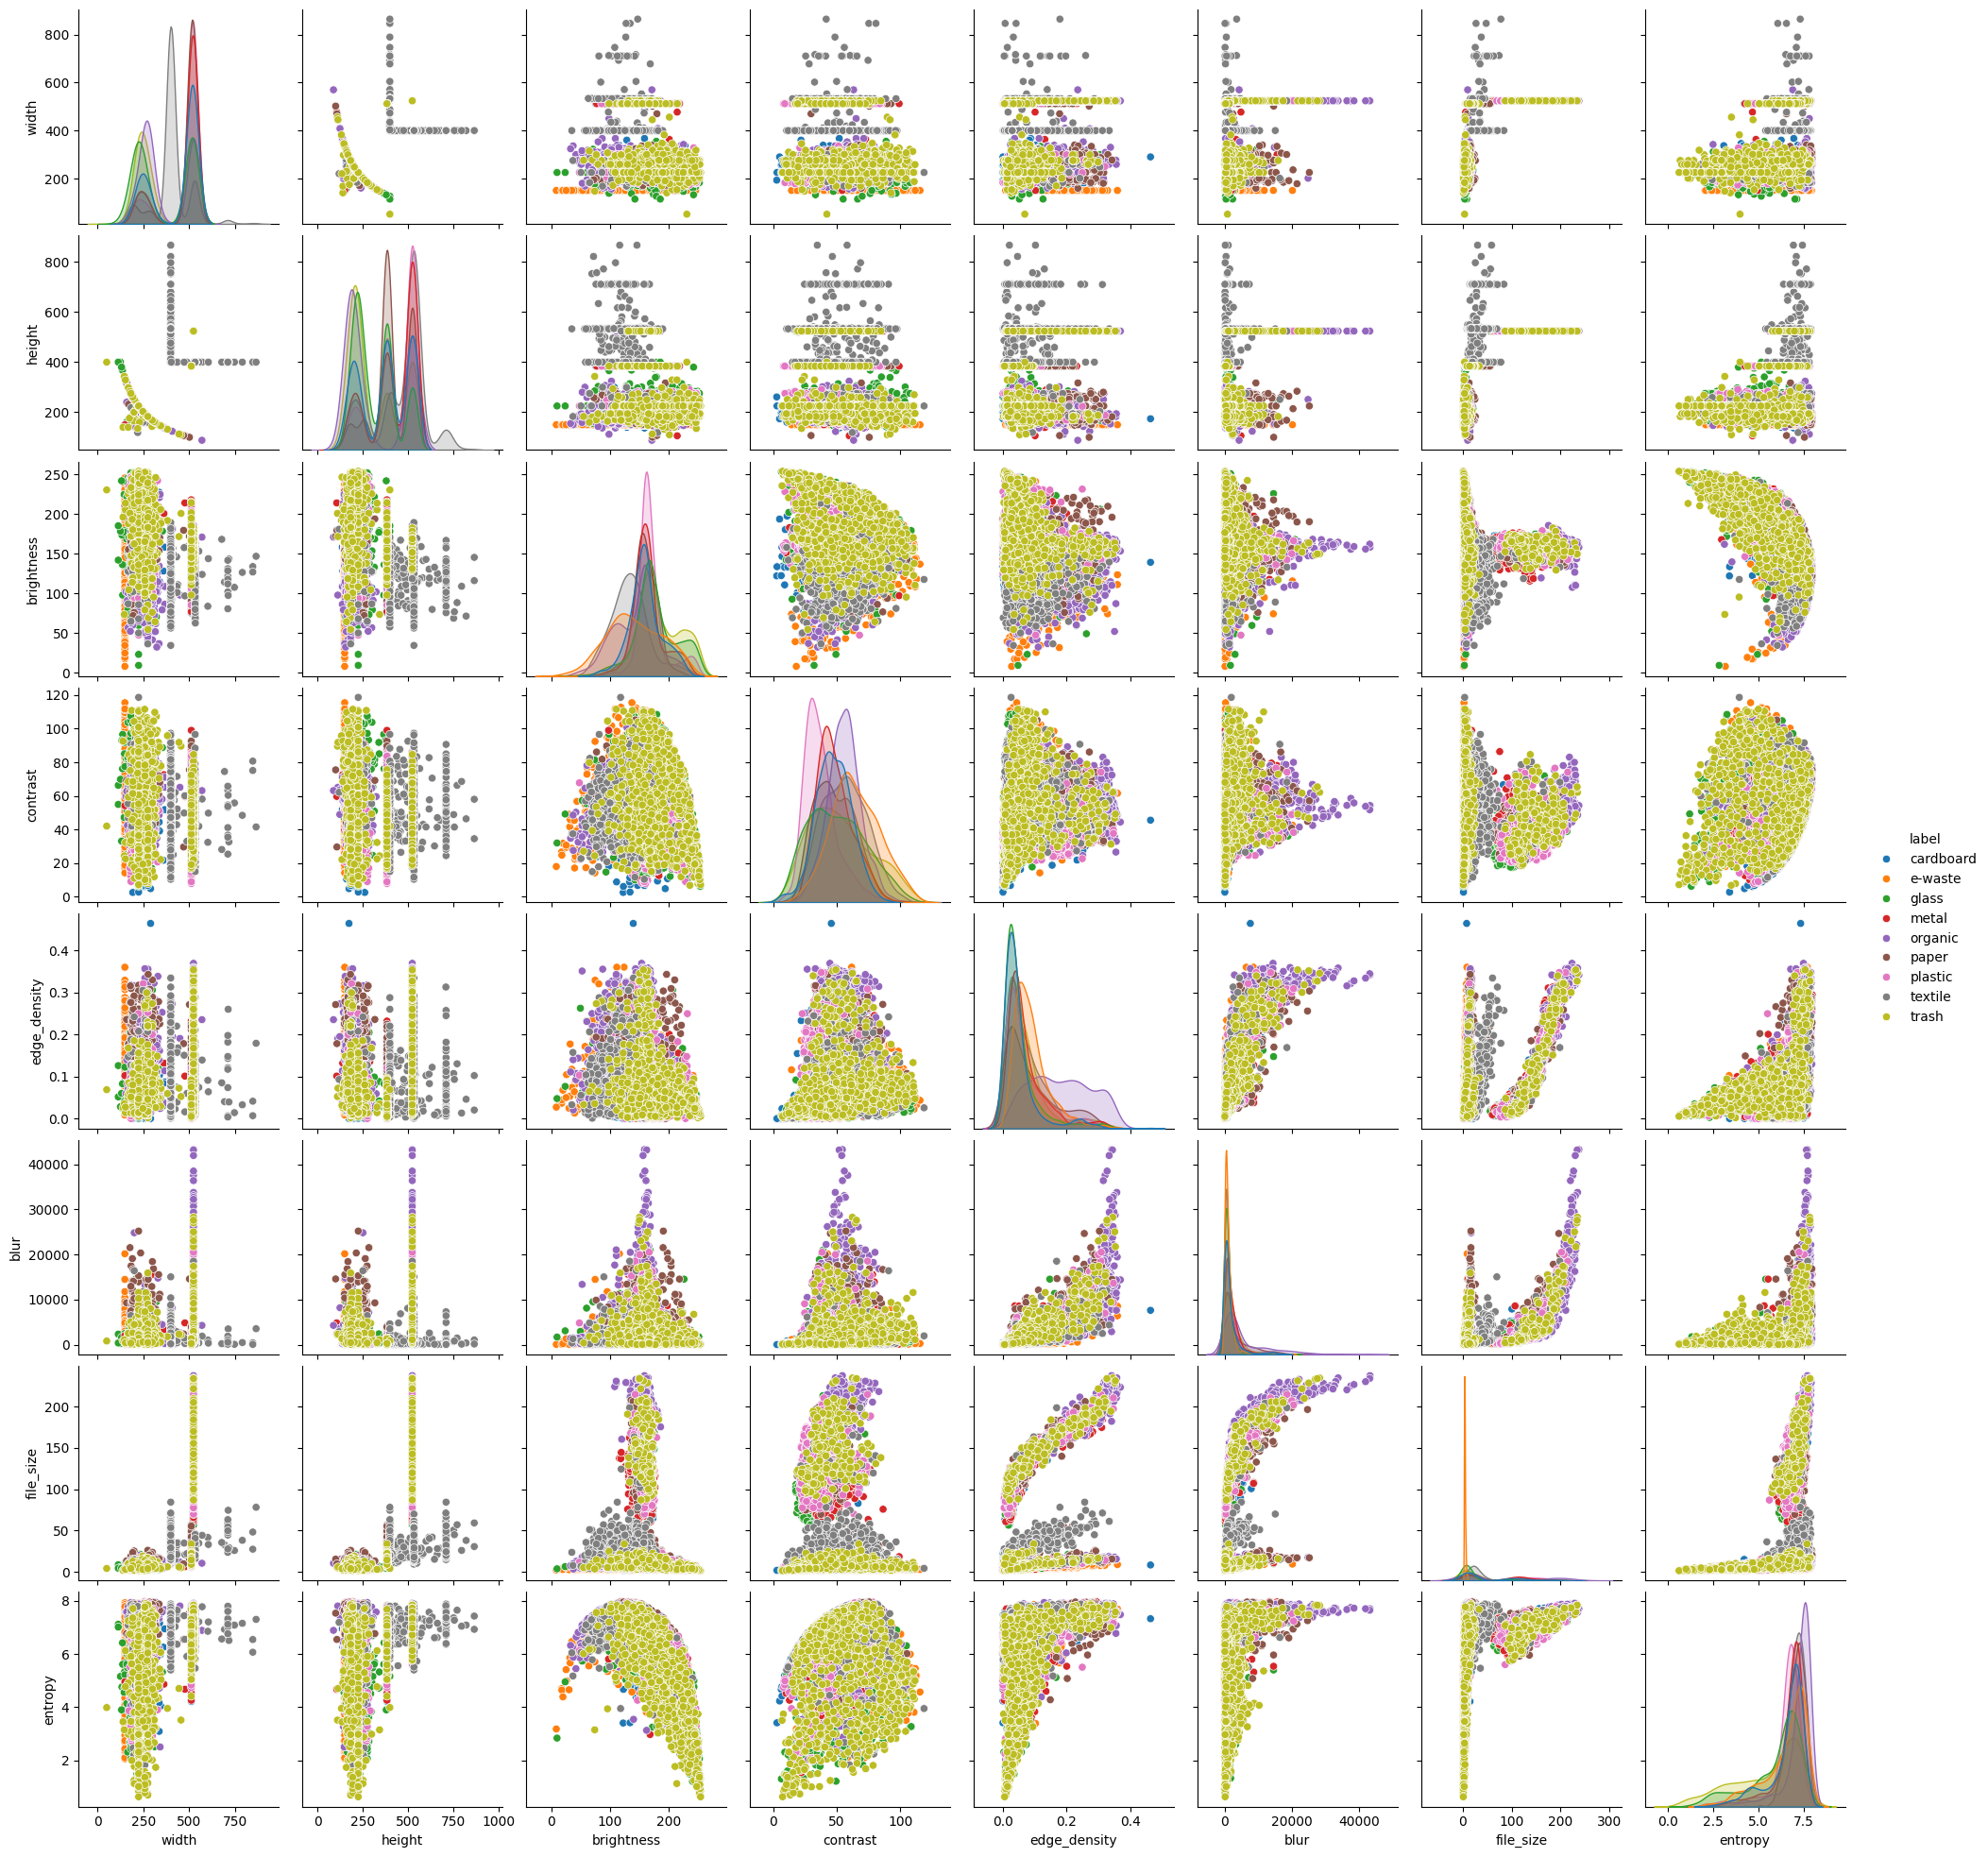

In [38]:
#Pairwise feature relationships - multi-variable patterns

sns.pairplot(df,hue="label")

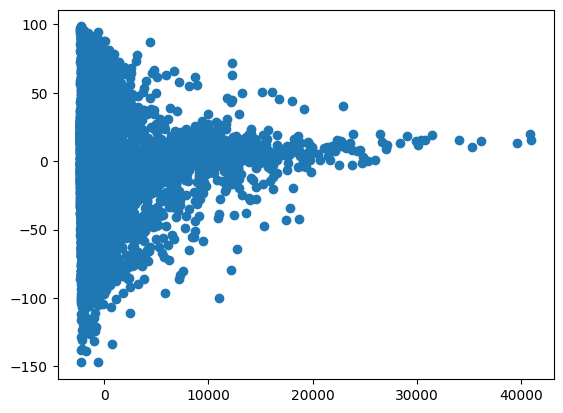

In [39]:
#PCA projection - feature separability

from sklearn.decomposition import PCA

features=df[['brightness','contrast','edge_density','blur','entropy']]

X=PCA(n_components=2).fit_transform(features)

plt.scatter(X[:,0],X[:,1])

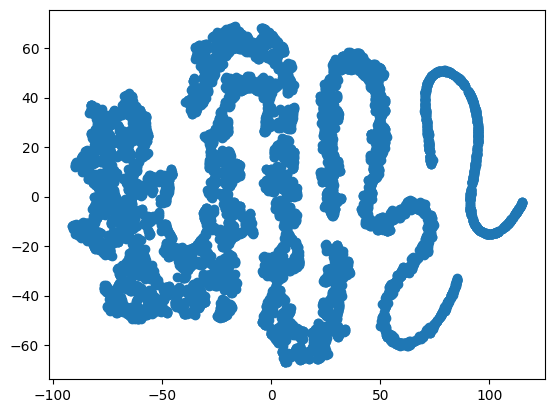

In [40]:
#t-SNE projection - class clustering potential

from sklearn.manifold import TSNE

X=TSNE(n_components=2).fit_transform(features)

plt.scatter(X[:,0],X[:,1])

<Axes: xlabel='brightness', ylabel='contrast'>

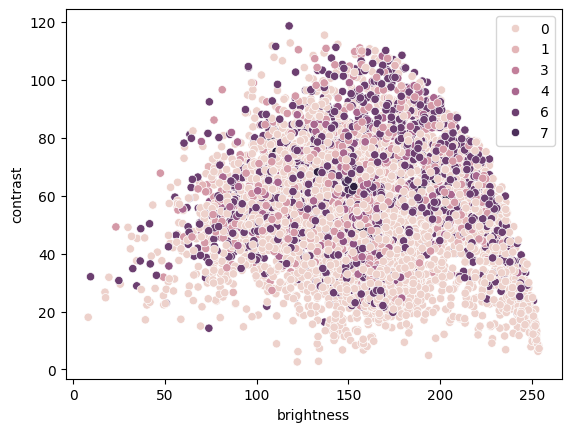

In [41]:
#KMeans cluster analysis - natural grouping of waste types

from sklearn.cluster import KMeans

clusters=KMeans(n_clusters=9).fit_predict(features)

sns.scatterplot(x=features.iloc[:,0],y=features.iloc[:,1],hue=clusters)